# 06 — YOLO26n Baseline Comparison

This notebook trains a YOLO26n baseline on VisDrone and compares its mAP@50 against the
YOLOv8n baseline, CBAM-enhanced YOLOv8n, pseudo-labeled YOLOv8n, and YOLOv11n baseline.

**Pipeline:**
1. Install `ultralytics` (YOLO26 is included in the latest versions)
2. Mount Google Drive and locate the project root
3. Download and convert the VisDrone dataset (if not already present)
4. Train YOLO26n for 20 epochs
5. Evaluate and save metrics to `results/metrics.json`
6. Generate a comparison bar chart saved to `results/`

## Install Dependencies

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.7 MB/s eta 0:00:00


## Mount Google Drive and Set Working Directory

In [2]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

candidate_paths = [
    Path('/content/drive/MyDrive/uav-small-object-detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector/UAV_small_obj_detector'),
    Path('/content/drive/MyDrive/UAV_small_obj_detector'),
]

project_root = next((p for p in candidate_paths if p.exists()), None)
if project_root is None:
    raise FileNotFoundError(
        'Could not find the project folder in Google Drive. '
        'Check MyDrive/uav-small-object-detector and MyDrive/UAV_small_obj_detector.'
    )

os.chdir(project_root)
print(f'Project root: {project_root}')
!pwd

Mounted at /content/drive
Project root: /content/drive/MyDrive/UAV_small_obj_detector
/content/drive/MyDrive/UAV_small_obj_detector


## Download VisDrone Dataset (if not already on disk)

In [3]:
import shutil
from PIL import Image
from ultralytics.utils.downloads import download

dataset_root = Path('/content/VisDrone')


def visdrone2yolo(root, split, source_name):
    source_dir = root / source_name
    images_dir = root / 'images' / split
    labels_dir = root / 'labels' / split
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    for img in (source_dir / 'images').glob('*.jpg'):
        shutil.move(str(img), str(images_dir / img.name))

    for ann in (source_dir / 'annotations').glob('*.txt'):
        img_path = images_dir / ann.with_suffix('.jpg').name
        img_w, img_h = Image.open(img_path).size
        dw, dh = 1.0 / img_w, 1.0 / img_h
        lines = []

        with open(ann, encoding='utf-8') as f:
            rows = [x.split(',') for x in f.read().strip().splitlines()]

        for row in rows:
            if row[4] != '0':
                x, y, w, h = map(int, row[:4])
                cls = int(row[5]) - 1
                x_center = (x + w / 2) * dw
                y_center = (y + h / 2) * dh
                w_norm = w * dw
                h_norm = h * dh
                lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n')

        with open(labels_dir / ann.name, 'w', encoding='utf-8') as out:
            out.writelines(lines)


if not (dataset_root / 'images' / 'val').exists():
    urls = [
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip',
    ]
    download(urls, dir=dataset_root, threads=4)

    for folder, split in {
        'VisDrone2019-DET-train': 'train',
        'VisDrone2019-DET-val': 'val',
        'VisDrone2019-DET-test-dev': 'test',
    }.items():
        visdrone2yolo(dataset_root, split, folder)
        shutil.rmtree(dataset_root / folder)

print(f"Train images found: {len(os.listdir('/content/VisDrone/images/train'))}")
print(f"Validation images found: {len(os.listdir('/content/VisDrone/images/val'))}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping /content/VisDrone/VisDrone2019-DET-val.zip to /content/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 911.5files/s 1.2s
Unzipping /content/VisDrone/VisDrone2019-DET-test-dev.zip to /content/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 1.4Kfiles/s 2.3s
Unzipping /content/VisDrone/VisDrone2019-DET-train.zip to /content/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.6Kfiles/s 8.0s
Train images found: 6471
Validation images found: 548


## Write VisDrone YAML Config

In [4]:
%%writefile visdrone.yaml
path: /content/VisDrone
train: images/train
val: images/val
nc: 10
names: ['pedestrian','people','bicycle','car','van','truck',
        'tricycle','awning-tricycle','bus','motor']

Overwriting visdrone.yaml


## Train YOLO26n Baseline

In [5]:
from ultralytics import YOLO

model = YOLO('yolo26n.pt')

model.train(
    data='visdrone.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    name='yolo26n_baseline',
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef6df4993d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

## Evaluate on Validation Split

In [6]:
val_results = model.val(data='visdrone.yaml')

print('Metrics:')
print(f'mAP50:     {val_results.box.map50:.4f}')
print(f'mAP50-95:  {val_results.box.map:.4f}')
print(f'Precision: {val_results.box.mp:.4f}')
print(f'Recall:    {val_results.box.mr:.4f}')

yolo26_metrics = {
    'mAP50':     float(val_results.box.map50),
    'mAP50-95':  float(val_results.box.map),
    'precision': float(val_results.box.mp),
    'recall':    float(val_results.box.mr),
}

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1793.2±1100.8 MB/s, size: 126.7 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 229.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.5it/s 10.1s
                   all        548      38759      0.368      0.291      0.249      0.137
            pedestrian        520       8844      0.335       0.37      0.286      0.112
                people        482       5125      0.437      0.232      0.214       0.07
               bicycle        364       1287      0.166     0.0562     0.0336     0.0129
                   car        515      14064      0.527      0.717      0.669      0.426
                   van        421       197

## Save Results to `results/metrics.json`

In [7]:
import json

os.makedirs('results', exist_ok=True)
metrics_path = Path('results/metrics.json')

if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        all_metrics = json.load(f)
else:
    all_metrics = {}

all_metrics['yolo26n_baseline'] = yolo26_metrics

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, indent=2)

print('Updated metrics.json:')
print(json.dumps(all_metrics, indent=2))

Updated metrics.json:
{
  "yolov11n_baseline": {
    "mAP50": 0.2651762490537308,
    "mAP50-95": 0.14755468472085892,
    "precision": 0.38817470697606105,
    "recall": 0.3011898452484491
  },
  "yolo26n_baseline": {
    "mAP50": 0.24941439738801044,
    "mAP50-95": 0.13737889200958459,
    "precision": 0.36771093891145196,
    "recall": 0.29103506090333614
  }
}


## Save Detection Samples (First 5 Validation Images)


image 1/1 /content/VisDrone/images/val/0000001_02999_d_0000005.jpg: 384x640 3 pedestrians, 1 people, 10 cars, 7 motors, 58.6ms
Speed: 3.2ms preprocess, 58.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Saved sample 0 to results/detection_samples/yolo26/sample_0.jpg

image 1/1 /content/VisDrone/images/val/0000001_03499_d_0000006.jpg: 384x640 9 pedestrians, 1 people, 1 bicycle, 12 cars, 3 vans, 1 tricycle, 1 awning-tricycle, 4 motors, 9.6ms
Speed: 2.1ms preprocess, 9.6ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
Saved sample 1 to results/detection_samples/yolo26/sample_1.jpg

image 1/1 /content/VisDrone/images/val/0000001_03999_d_0000007.jpg: 384x640 3 pedestrians, 2 peoples, 3 cars, 1 tricycle, 1 awning-tricycle, 5 motors, 10.3ms
Speed: 2.7ms preprocess, 10.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Saved sample 2 to results/detection_samples/yolo26/sample_2.jpg

image 1/1 /content/VisDrone/images/val/0000001_04527_

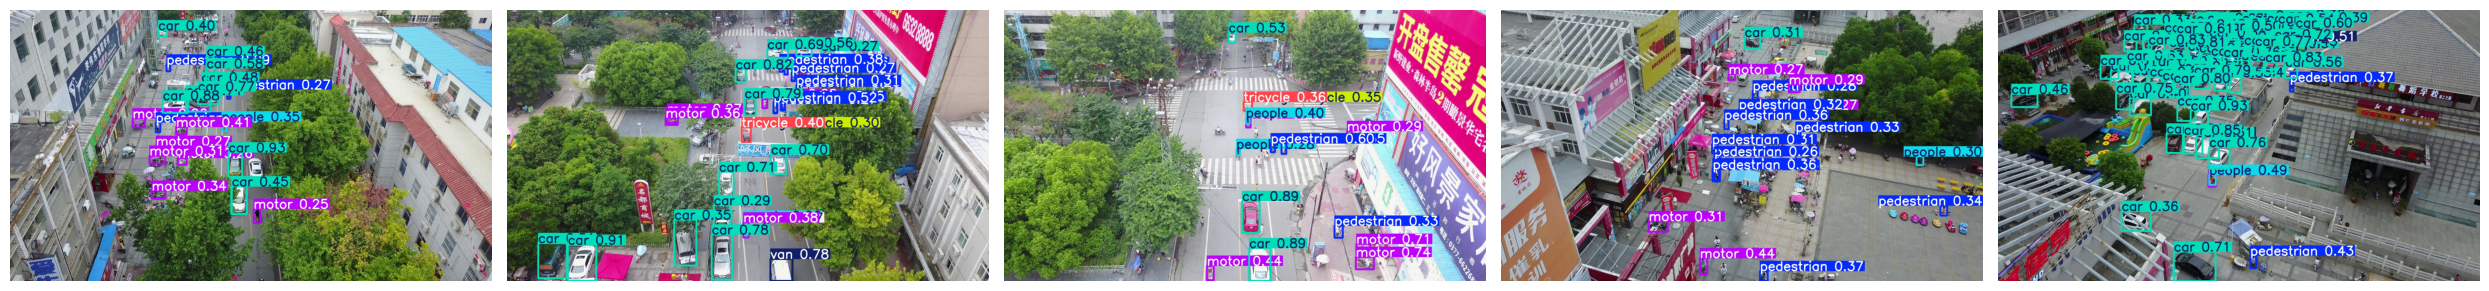

In [8]:
import cv2
import matplotlib.pyplot as plt

sample_dir = Path('results/detection_samples/yolo26')
sample_dir.mkdir(parents=True, exist_ok=True)

val_images = sorted(Path('/content/VisDrone/images/val').glob('*.jpg'))[:5]
for idx, img_path in enumerate(val_images):
    results = model(img_path)
    annotated = results[0].plot()  # BGR numpy array
    save_path = str(sample_dir / f'sample_{idx}.jpg')
    cv2.imwrite(save_path, annotated)
    print(f'Saved sample {idx} to {save_path}')

# Display inline
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, samp in zip(axes, sorted(sample_dir.glob('sample_*.jpg'))):
    img = cv2.imread(str(samp))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Generate Comparison Bar Chart (All Models)

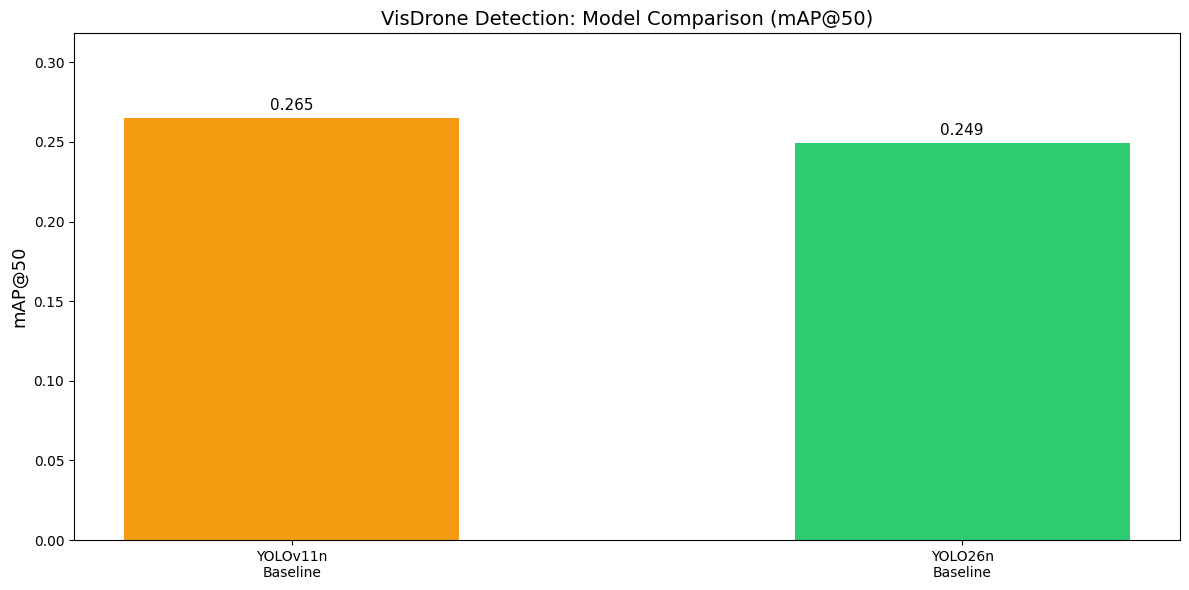

Chart saved to results/model_comparison_bar.png


In [9]:
import matplotlib.pyplot as plt
import json
from pathlib import Path

with open('results/metrics.json', 'r', encoding='utf-8') as f:
    all_metrics = json.load(f)

label_map = {
    'baseline':          'YOLOv8n\nBaseline',
    'cbam':              'YOLOv8n\n+ CBAM',
    'pseudo_label':      'YOLOv8n\n+ Pseudo',
    'yolov11n_baseline': 'YOLOv11n\nBaseline',
    'yolo26n_baseline':  'YOLO26n\nBaseline',
}
color_map = {
    'baseline':          '#3498db',
    'cbam':              '#e74c3c',
    'pseudo_label':      '#9b59b6',
    'yolov11n_baseline': '#f39c12',
    'yolo26n_baseline':  '#2ecc71',
}

labels, scores, colors = [], [], []
for key, label in label_map.items():
    if key in all_metrics and 'mAP50' in all_metrics[key]:
        labels.append(label)
        scores.append(all_metrics[key]['mAP50'])
        colors.append(color_map[key])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, scores, color=colors, width=0.5)
ax.set_ylabel('mAP@50', fontsize=13)
ax.set_title('VisDrone Detection: Model Comparison (mAP@50)', fontsize=14)
ax.set_ylim(0, max(scores) * 1.2)

for bar, v in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.005,
        f'{v:.3f}',
        ha='center',
        fontsize=11,
    )

plt.tight_layout()
plt.savefig('results/model_comparison_bar.png', dpi=150)
plt.show()
print('Chart saved to results/model_comparison_bar.png')

## Results Summary

| Model | mAP@50 |
|---|---|
| YOLOv8n Baseline | 0.294 |
| YOLOv8n + CBAM | 0.302 |
| YOLOv8n + Pseudo-Labels | 0.307 |
| YOLOv11n Baseline | (from previous run) |
| YOLO26n Baseline | *(from this run)* |

All metrics are persisted in `results/metrics.json` on Google Drive.